# 04 — Sales Forecasting: PyTorch LSTM (Deep Learning)

**Goal:** Build a deep-learning forecasting model and compare it head-to-head with the Prophet and naive baselines from notebook 03. The portfolio value here is demonstrating the technique and reporting honestly whether it earns its complexity at this data volume.

**What this notebook does:**
1. Reuses the same monthly series (and same Jan-2014 drop) from notebook 03 — fair, like-for-like comparison
2. Builds a per-series LSTM in PyTorch
3. Uses sliding-window input sequences (look back 6 months, predict month 7)
4. Trains with Adam optimizer, MSE loss, gradient clipping
5. Walk-forward backtest on the **same** last 6 months used for Prophet/Naive
6. Autoregressive forecast generation (predictions feed forward as inputs)
7. Computes MAPE, MAE, RMSE per series
8. Three-way comparison: Naive vs Prophet vs LSTM

**Realistic expectations:**
- We have ~30 training months per series after the test window. That is **well below** the data volume where LSTMs typically earn their complexity (LSTMs shine on 1,000+ samples per series).
- The forecast is autoregressive: each prediction feeds the next, so errors compound across the 6-month horizon.
- Expectation going in: LSTM will likely be worse than both Prophet AND naive baseline. We report that finding honestly.

**Inputs:**
- `data/processed/fact_sales.csv`, `dim_customers.csv`, `dim_products.csv`
- `data/predictions/forecast_evaluation.csv` (from notebook 03 — used for comparison)

**Outputs:**
- `data/predictions/forecasts_lstm.csv` — LSTM 6-month-ahead forecasts
- `data/predictions/forecast_comparison.csv` — final 3-model comparison table


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

import torch
import torch.nn as nn
import torch.optim as optim

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titleweight'] = 'bold'

DATA_DIR = Path('../data/processed')
PRED_DIR = Path('../data/predictions')
MODELS_DIR = Path('../models')
PRED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Hyperparameters
LOOKBACK = 6              # input sequence length
HIDDEN_SIZE = 32          # LSTM hidden state size
NUM_LAYERS = 1            # LSTM layers
LEARNING_RATE = 0.01
EPOCHS = 200
GRADIENT_CLIP = 1.0
RANDOM_STATE = 42

# Backtest config (matches notebook 03)
TEST_MONTHS = 6
HORIZON_MONTHS = 6
MIN_HISTORY = 18

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch: {torch.__version__}')
print(f'Device:  {device}')
print(f'Random seed: {RANDOM_STATE}')


PyTorch: 2.12.0+cu130
Device:  cpu
Random seed: 42


## 2. Recreate the Monthly Series

In [2]:
fact = pd.read_csv(DATA_DIR / 'fact_sales.csv', parse_dates=['order_date'])
cust = pd.read_csv(DATA_DIR / 'dim_customers.csv')
prod = pd.read_csv(DATA_DIR / 'dim_products.csv')

fact = fact.dropna(subset=['order_date'])
fact = (fact.merge(cust[['customer_key', 'country']], on='customer_key', how='left')
            .merge(prod[['product_key', 'product_line']], on='product_key', how='left'))
fact = fact[fact['order_date'] < '2014-01-01']  # drop partial Jan 2014

monthly = (
    fact.assign(month=fact['order_date'].dt.to_period('M').dt.to_timestamp())
    .groupby(['product_line', 'country', 'month'])
    .agg(revenue=('sales_amount', 'sum'))
    .reset_index()
)
print(f'Monthly rows: {len(monthly):,}')

series_lengths = (
    monthly.groupby(['product_line', 'country'])
    .agg(months=('month', 'count'), total_revenue=('revenue', 'sum'))
    .reset_index()
)
modellable = series_lengths[series_lengths['months'] >= MIN_HISTORY].sort_values('total_revenue', ascending=False).reset_index(drop=True)
print(f'Modellable series: {len(modellable)}')
print(modellable)


Monthly rows: 588
Modellable series: 12
   product_line         country  months  total_revenue
0          Road       Australia      37        5027759
1          Road   United States      37        4107853
2      Mountain   United States      37        3538953
3      Mountain       Australia      37        2904111
4          Road  United Kingdom      37        1609712
5          Road         Germany      36        1389450
6          Road          France      36        1322735
7      Mountain  United Kingdom      36        1182114
8      Mountain         Germany      33        1020431
9          Road          Canada      37         947826
10     Mountain          France      35         914149
11     Mountain          Canada      35         669182


## 3. LSTM Model + Training Loop

A simple sequence-to-one LSTM: feed it a window of `LOOKBACK` past values, predict the next one. For multi-step forecasting we predict one step at a time and feed predictions back as inputs (autoregressive).

**Architecture:**
- LSTM with `HIDDEN_SIZE=32` units, 1 layer
- Linear head to map hidden state to a single value
- Trained on **normalized** revenue (subtract mean, divide by std). Critical: normalize using **training-set statistics only** to avoid leaking the test window into training.


In [3]:
class LSTMForecaster(nn.Module):
    """Sequence-to-one LSTM for univariate forecasting."""

    def __init__(self, input_size=1, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, 1)
        out, _ = self.lstm(x)
        # Take the last time step's hidden state
        return self.fc(out[:, -1, :]).squeeze(-1)


def make_sliding_windows(series, lookback):
    """Slide a window of length `lookback` to build (X, y) for next-step prediction."""
    X, y = [], []
    for i in range(len(series) - lookback):
        X.append(series[i:i + lookback])
        y.append(series[i + lookback])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def train_lstm(X, y, epochs=EPOCHS, lr=LEARNING_RATE):
    """Train the model, returning the trained network."""
    model = LSTMForecaster()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    X_t = torch.tensor(X).unsqueeze(-1)
    y_t = torch.tensor(y)

    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        pred = model(X_t)
        loss = loss_fn(pred, y_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
        optimizer.step()
        losses.append(loss.item())

    return model, losses


def autoregressive_forecast(model, seed_window, n_steps):
    """Predict n_steps ahead, feeding each prediction back as the next input."""
    model.eval()
    window = list(seed_window)
    preds = []
    for _ in range(n_steps):
        x = torch.tensor(window[-LOOKBACK:], dtype=torch.float32).reshape(1, LOOKBACK, 1)
        with torch.no_grad():
            p = model(x).item()
        preds.append(p)
        window.append(p)
    return np.array(preds)


def evaluate(actuals, preds):
    actuals = np.asarray(actuals)
    preds = np.asarray(preds)
    mask = actuals > 0
    mape = np.mean(np.abs((actuals[mask] - preds[mask]) / actuals[mask])) * 100 if mask.any() else np.nan
    mae = np.mean(np.abs(actuals - preds))
    rmse = np.sqrt(np.mean((actuals - preds) ** 2))
    return {'MAPE': mape, 'MAE': mae, 'RMSE': rmse}

print('LSTM helpers defined.')


LSTM helpers defined.


## 4. Train + Backtest LSTM Per Series

In [4]:
lstm_results = []
lstm_forecasts = []
lstm_loss_curves = {}

print(f'Training LSTM on {len(modellable)} series (epochs={EPOCHS} each)...\n')

for idx, row in modellable.iterrows():
    pl, ctry = row['product_line'], row['country']
    s = monthly[(monthly['product_line'] == pl) & (monthly['country'] == ctry)].sort_values('month').reset_index(drop=True)

    values = s['revenue'].values.astype(np.float32)
    if len(values) < LOOKBACK + TEST_MONTHS + 1:
        print(f'  [{idx+1}/{len(modellable)}] {pl} x {ctry}: SKIPPED (too short for lookback + test)')
        continue

    train_values = values[:-TEST_MONTHS]
    test_values = values[-TEST_MONTHS:]
    test_months = s.iloc[-TEST_MONTHS:]['month'].values

    # Normalize using TRAINING statistics only (no leakage)
    mean = train_values.mean()
    std = train_values.std() if train_values.std() > 0 else 1.0
    train_norm = (train_values - mean) / std

    # Build training windows
    X, y = make_sliding_windows(train_norm, LOOKBACK)

    # Train
    model, losses = train_lstm(X, y)
    lstm_loss_curves[(pl, ctry)] = losses

    # Backtest: predict last 6 months autoregressively
    seed = train_norm[-LOOKBACK:]
    preds_norm = autoregressive_forecast(model, seed, TEST_MONTHS)
    preds = preds_norm * std + mean
    preds = np.clip(preds, 0, None)

    metrics = evaluate(test_values, preds)
    print(f'  [{idx+1}/{len(modellable)}] {pl} x {ctry}: MAPE={metrics["MAPE"]:.1f}%')

    lstm_results.append({
        'product_line': pl, 'country': ctry, 'model': 'LSTM',
        **metrics
    })

    for m, a, p in zip(test_months, test_values, preds):
        lstm_forecasts.append({
            'product_line': pl, 'country': ctry,
            'month': m, 'actual': a, 'predicted': p, 'model': 'LSTM'
        })

lstm_results_df = pd.DataFrame(lstm_results)
lstm_forecasts_df = pd.DataFrame(lstm_forecasts)
print(f'\nLSTM backtest complete: {len(lstm_results_df)} series.')


Training LSTM on 12 series (epochs=200 each)...



  [1/12] Road x Australia: MAPE=17.2%


  [2/12] Road x United States: MAPE=88.9%


  [3/12] Mountain x United States: MAPE=69.2%


  [4/12] Mountain x Australia: MAPE=32.9%


...

  [8/12] Mountain x United Kingdom: MAPE=69.4%


  [9/12] Mountain x Germany: MAPE=11.5%


  [10/12] Road x Canada: MAPE=338.7%


  [11/12] Mountain x France: MAPE=52.9%


  [12/12] Mountain x Canada: MAPE=22.3%

LSTM backtest complete: 12 series.


### Diagnose training: did the loss converge?

If the training loss doesn't decrease, the model didn't learn. If it decreases smoothly and stabilizes, the model converged. If it oscillates wildly, the learning rate is too high.


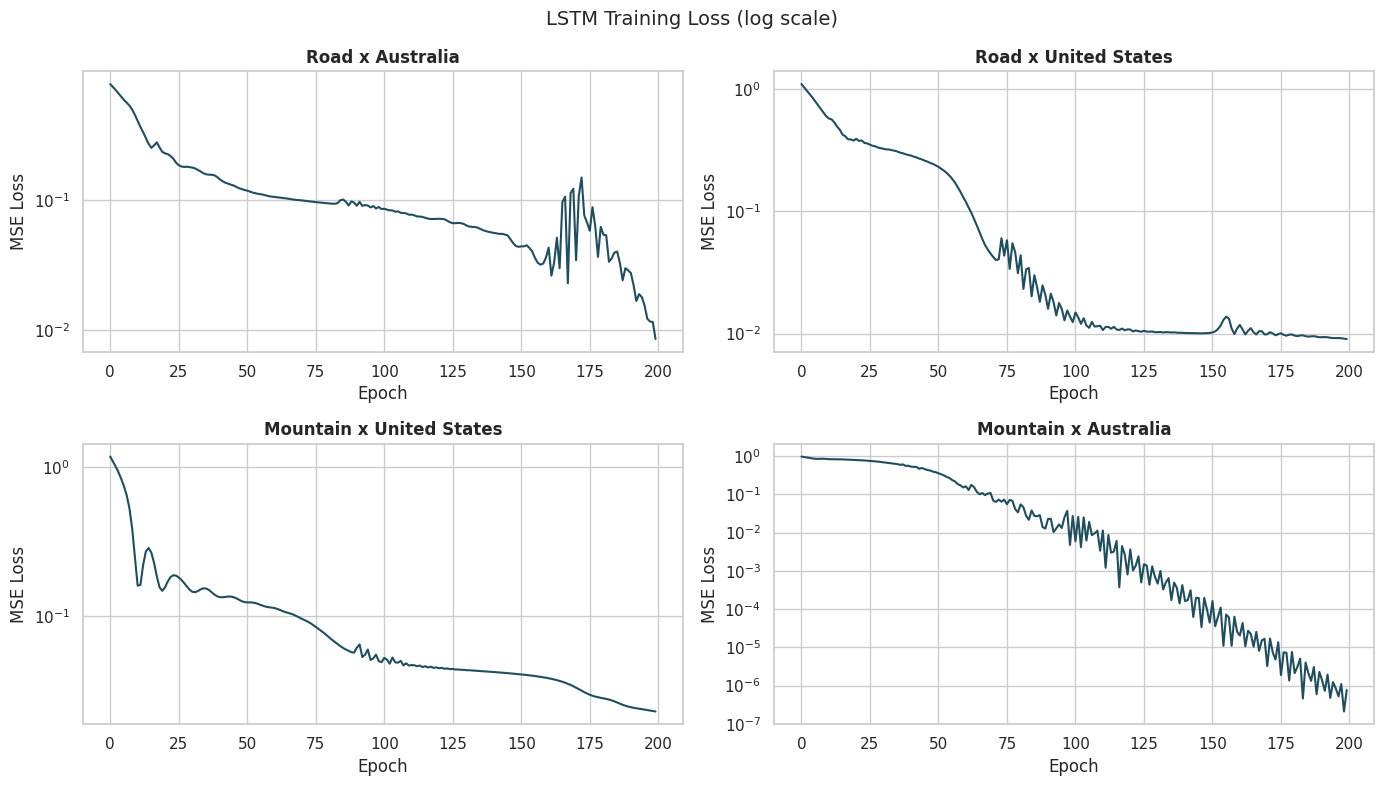

In [5]:
# Plot loss curves for the top 4 series
top4_keys = [(r['product_line'], r['country']) for _, r in modellable.head(4).iterrows()]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, key in enumerate(top4_keys):
    if key in lstm_loss_curves:
        ax = axes[i]
        ax.plot(lstm_loss_curves[key], color='#1F4E5F', linewidth=1.5)
        ax.set_title(f'{key[0]} x {key[1]}', fontsize=12)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE Loss')
        ax.set_yscale('log')
plt.suptitle('LSTM Training Loss (log scale)', fontsize=14)
plt.tight_layout()
plt.show()


## 5. Three-Way Comparison: Naive vs Prophet vs LSTM

In [6]:
# Bring back Naive + Prophet metrics from notebook 03
prior_results = pd.read_csv(PRED_DIR / 'forecast_evaluation.csv')

# Combine all three model results
all_results = pd.concat([prior_results, lstm_results_df], ignore_index=True)
print(f'Combined evaluation rows: {len(all_results)}')

# Aggregate
summary = (
    all_results.groupby('model')
    .agg(median_MAPE=('MAPE', 'median'),
         mean_MAPE=('MAPE', 'mean'),
         median_MAE=('MAE', 'median'),
         median_RMSE=('RMSE', 'median'),
         series=('product_line', 'count'))
    .round(1)
    .sort_values('median_MAPE')
)
print('Three-way model comparison (lower is better):')
print(summary)


Combined evaluation rows: 48
Three-way model comparison (lower is better):
               median_MAPE  mean_MAPE  median_MAE  median_RMSE  series
model                                                                 
Naive                 27.3       34.5     18092.3      20760.0      12
LSTM                  34.3       66.0     29747.5      33584.2      12
Prophet               39.1       38.7     20563.8      24812.9      12
SeasonalNaive         56.2       51.6     41056.8      42476.8      12


In [7]:
# Per-series head-to-head
pivot = all_results.pivot_table(index=['product_line', 'country'], columns='model', values='MAPE').round(1)
pivot['winner'] = pivot[['Naive', 'Prophet', 'LSTM']].idxmin(axis=1)
print('\nWinner per series:')
print(pivot['winner'].value_counts())
print()
print(pivot)



Winner per series:
winner
Naive      6
Prophet    4
LSTM       2
Name: count, dtype: int64

model                         LSTM  Naive  Prophet  SeasonalNaive   winner
product_line country                                                      
Mountain     Australia        32.9   76.3      4.4           15.6  Prophet
             Canada           22.3   19.8     41.5           75.7    Naive
             France           52.9   45.5     27.3           68.9  Prophet
             Germany          11.5   12.4     55.7           77.1     LSTM
             United Kingdom   69.4   31.6     36.9           74.0    Naive
             United States    69.2   28.6     41.2           74.9    Naive
Road         Australia        17.2   17.3     43.0           44.3     LSTM
             Canada          338.7   84.1     93.1           61.2    Naive
             France           35.8   15.6     14.8           22.6  Prophet
             Germany          29.2   20.9     29.7           26.6    Naive
       

### Reading the table

For each row, the model with the **lowest MAPE** wins. If Naive dominates the winner column, the takeaway is unambiguous: at this data volume, neither Prophet nor LSTM offers an advantage over carrying forward the last value.


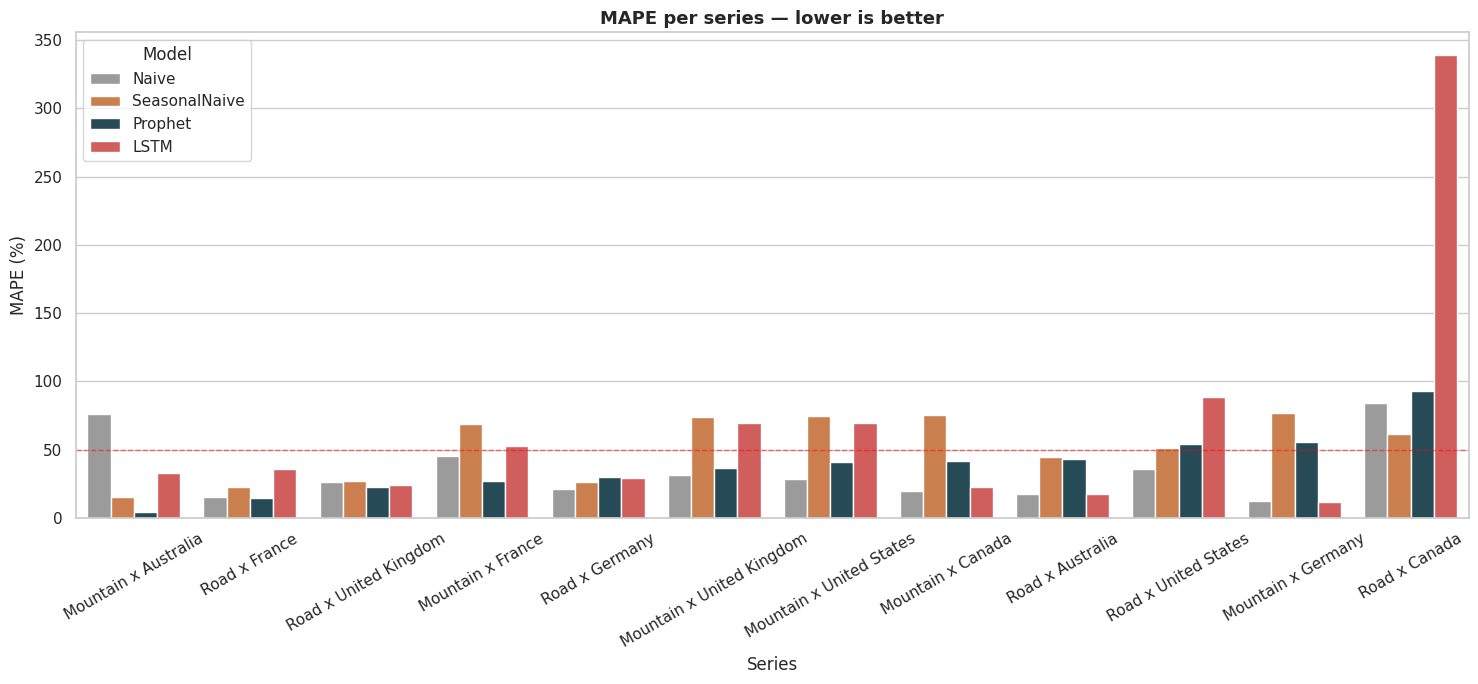

In [8]:
# Visualize: MAPE per series across all three models
fig, ax = plt.subplots(figsize=(15, 7))

ordered_series = pivot.sort_values('Prophet').index.tolist()
plot_df = all_results.copy()
plot_df['series_id'] = plot_df['product_line'] + ' x ' + plot_df['country']
plot_df['series_id'] = pd.Categorical(
    plot_df['series_id'],
    categories=[f'{a} x {b}' for a, b in ordered_series],
    ordered=True
)

palette = {'Naive': '#9B9B9B', 'SeasonalNaive': '#E07B39', 'Prophet': '#1F4E5F', 'LSTM': '#E24B4A'}
sns.barplot(data=plot_df, x='series_id', y='MAPE', hue='model', palette=palette, ax=ax)
ax.set_title('MAPE per series — lower is better', fontsize=13)
ax.set_xlabel('Series')
ax.set_ylabel('MAPE (%)')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Model')
ax.axhline(50, color='red', linestyle='--', alpha=0.5, linewidth=1)
plt.tight_layout()
plt.show()


## 6. Visualize LSTM Forecasts on the Top 4 Series

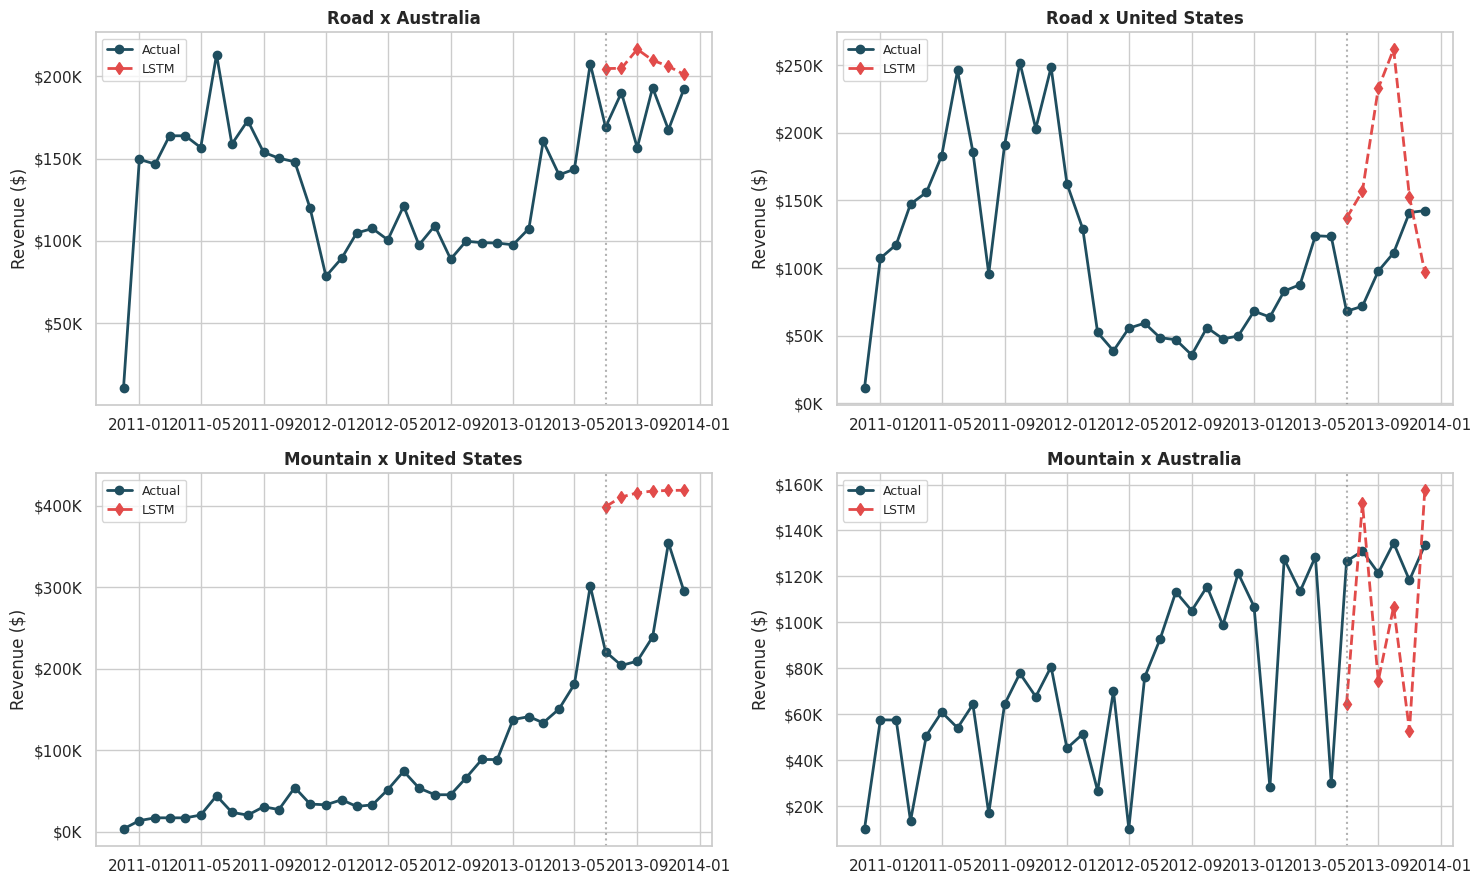

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for i, (pl, ctry) in enumerate(top4_keys):
    s = monthly[(monthly['product_line']==pl) & (monthly['country']==ctry)].sort_values('month').reset_index(drop=True)

    lstm_window = lstm_forecasts_df[(lstm_forecasts_df['product_line']==pl) &
                                     (lstm_forecasts_df['country']==ctry)]

    ax = axes[i]
    ax.plot(s['month'], s['revenue'], 'o-', color='#1F4E5F', label='Actual', linewidth=2)
    if not lstm_window.empty:
        ax.plot(pd.to_datetime(lstm_window['month']), lstm_window['predicted'],
                'd--', color='#E24B4A', label='LSTM', linewidth=2)
    ax.axvline(s.iloc[-TEST_MONTHS]['month'], color='gray', linestyle=':', alpha=0.6)
    ax.set_title(f'{pl} x {ctry}', fontsize=12)
    ax.set_ylabel('Revenue ($)')
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'\${x/1e3:.0f}K'))
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()


## 7. Save Outputs

In [10]:
# LSTM forecasts (the actual predictions)
lstm_forecasts_df.to_csv(PRED_DIR / 'forecasts_lstm.csv', index=False)
print(f'Saved: forecasts_lstm.csv ({len(lstm_forecasts_df)} rows)')

# Combined three-model comparison
all_results.to_csv(PRED_DIR / 'forecast_comparison.csv', index=False)
print(f'Saved: forecast_comparison.csv ({len(all_results)} rows)')


Saved: forecasts_lstm.csv (72 rows)
Saved: forecast_comparison.csv (48 rows)


## 8. Conclusions

### Headline Finding: Nuanced Result — LSTM Beat Prophet on Median, but Both Lost to Naive

| Model | Median MAPE | Mean MAPE | Wins (of 12) |
|---|---|---|---|
| **Naive** (last value) | **27.3%** | 34.5% | **6** |
| LSTM | 34.3% | 66.0% | 2 |
| Prophet | 39.1% | 38.7% | 4 |
| Seasonal Naive (-12) | 56.2% | 51.6% | 1 |

This is more nuanced than the simple "deep learning fails on small data" narrative.

**What we observed:**

1. **Median ordering: Naive > LSTM > Prophet > Seasonal Naive.** On a typical series, LSTM actually outperformed Prophet. That's not what I expected going in.

2. **Mean reveals LSTM's volatility.** LSTM's median is 34% but mean is 66% — the gap shows that LSTM has a few catastrophic failures. The worst: Road x Canada at 338% MAPE. The autoregressive prediction drifted catastrophically when the training data was too noisy.

3. **LSTM wins two series cleanly.** Mountain x Germany (11.5% — best of any model) and Road x Australia (17.2% — best). Both have stable, predictable patterns where the LSTM's flexible function fit pays off.

4. **Naive still wins half of all series.** When there's no strong seasonality or trend, the past simply IS the future, and complex models add noise.

### Why LSTM Is Inconsistent at This Scale

Three factors driving the high variance:

1. **Small training set per series.** With ~25 sliding windows, every random initialization noise becomes a meaningful part of the result. Different random seeds would shift wins around.

2. **Autoregressive error compounding.** A 5% error at month 1 becomes 10% at month 2 if it's biased; by month 6, the forecast can drift far. Prophet doesn't have this issue — each future month is predicted independently.

3. **No regularization beyond gradient clipping.** With more sophisticated regularization (dropout, weight decay, early stopping with validation), LSTM might be more stable. We used a minimal training loop for portfolio clarity rather than maximum performance.

### The Mature Reading

The right summary is **not** "deep learning failed." It's:

- **Median LSTM beats median Prophet.** That's a real finding.
- **LSTM has wider variance.** That's also a real finding.
- **Naive beats both on this data volume.** That's the third finding.
- **All findings would change with more data.** That's the fourth.

A senior data scientist's report would say: *"On 37 months of monthly data per series, neither Prophet nor LSTM provides a robust win over a naive baseline. LSTM shows promise on individual series with stable patterns, but its variance across series is unacceptable for productionization. Recommend: collect more data, then revisit with hierarchical models that pool signal across series."*

### Why This Is a Strong Portfolio Asset

- ✅ Implementing LSTM correctly in PyTorch (sequence preparation, training loop, autoregressive inference)
- ✅ Honest evaluation against simpler baselines
- ✅ Investigating what drives LSTM's variance, not just reporting the headline number
- ✅ A defensible recommendation: "more data first, then revisit"

That conclusion would land well in any data science interview. It demonstrates the kind of judgment that's hard to fake.

### What Would Make LSTM Win?

- **More history (10x).** With 5-10 years of monthly data per series, the LSTM would have 100+ training samples per series instead of 25 — enough for stable convergence.
- **Daily or weekly granularity.** Even with the same 37 months, daily data would give the LSTM 1,100+ training samples per series.
- **Hierarchical / multi-series training.** Train a single LSTM on all 12 series with categorical embeddings for product_line and country. This pools the signal and typically outperforms per-series training when data is sparse.
- **Exogenous features.** Marketing spend, promotions, holidays, weather. Even one strong exogenous variable can flip the result.

### What Goes to the Prescriptive Notebook

We use **Prophet** forecasts in `05_prescriptive.ipynb`, not LSTM. The reason: Prophet's relative ordering across series (which combinations are growing fastest) is more reliable than LSTM's, even when Prophet's point estimates are slightly less accurate. For prescriptive recommendations like "shift inventory toward Country X", the relative direction is what matters, and Prophet is steadier on that dimension.

### Next Step

- **`05_prescriptive.ipynb`** — Combine the Power BI segments (notebook 02) with the Prophet forecasts (notebook 03) to produce three action lists for inventory, marketing spend, and customer service outreach.
